In [1]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

import matplotlib.pyplot as plt
import numpy as np

import laboneq
print(laboneq.__version__)

# Use this if you need to reset
# session.devices[f"SHFQC_{serial_num}"].factory_reset()

2.51.0


In [2]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""

descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12500
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/0/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""

In [3]:
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="ZI_test",  # setup name
)

# Are we emulating? or actually creating pulses?
emulate = True
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)


[2025.05.13 17:11:45.199] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\taekwany\OneDrive - Zurich Instruments AG\Desktop\ZI_Python\My_Codes\received_and_downloaded\UCLA\250513_qb_spec\laboneq_output\log
[2025.05.13 17:11:45.213] INFO    VERSION: laboneq 2.51.0
[2025.05.13 17:11:45.216] INFO    Connecting to data server at 127.0.0.1:8004
[2025.05.13 17:11:45.219] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.05.13 17:11:45.222] WARNING SHFQC/QA:dev12500: Include the device options 'SHFQC/QC6CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.05.13 17:11:45.223] INFO    Configuring the device setup
[2025.05.13 17:11:45.225] INFO    The device setup is configured


In [ ]:
# define experiment
def simple_test(
    exp_id="test_exp",
    average_exponent = 5,  # 2^n averages, n=average_exponent, maximum: n = 17. You can modify the code to average for any integer number if needed.
    freq_swp = LinearSweepParameter(uid = 'freq_swp_param', start = 390e6, stop = 420e6, count = 11),
    integration_length = 1e-6,
):
    # Create Experiment
    exp = Experiment(
        uid = exp_id,
        signals = [
            ExperimentSignal("qb_drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    sq_pulse = pulse_library.const(uid="square_pulse", length=0.4e-6, amplitude=1.)
    gauss_pulse = pulse_library.gaussian(uid="gauss_pulse", length=1e-6, amplitude=1.)
    readout_pulse = pulse_library.const(uid="readout_pulse", length=1e-6, amplitude=1.)
    
    with exp.acquire_loop_rt(
        uid="shots",
        count=pow(2, average_exponent),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp.sweep(uid="spect_sweep", parameter = freq_swp, reset_oscillator_phase = True,):
            with exp.section(uid="qb_excitation"):
                exp.play(signal="qb_drive", pulse = gauss_pulse)
            with exp.section(uid="readout", play_after="qb_excitation"):
                exp.measure(acquire_signal = "acquire", integration_length = integration_length, handle = f"ac_0",
                            reset_delay = 1000e-6)

    return exp

In [ ]:
swp_st = -100e6
swp_end = 100e6
swp_cnt = 101
freq_swp = LinearSweepParameter(uid = 'freq_swp_param', start = swp_st, stop = swp_end, count = swp_cnt)

exp_simple_test = simple_test(
    average_exponent = 8,
    freq_swp = freq_swp,
    integration_length = 500e-6,
    )

In [11]:
map_q0 = {}
map_q0['qb_drive'] = device_setup.logical_signal_groups["q0"].logical_signals["drive_line"]
map_q0['measure'] = device_setup.logical_signal_groups["q0"].logical_signals["measure_line"]
map_q0['acquire'] = device_setup.logical_signal_groups["q0"].logical_signals["acquire_line"]
exp_simple_test.set_signal_map(map_q0)

In [12]:
exp_calibration = Calibration()
exp_calibration["qb_drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = freq_swp,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = 5e9),
    range = 0,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = 100e6,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = 7.6e9),
    range = 0,
)
exp_calibration["acquire"] = SignalCalibration(
    range = 0,
)
exp_simple_test.set_calibration(exp_calibration)

In [13]:
compiled_simple_test = session.compile(exp_simple_test)

[2025.05.13 17:11:54.874] INFO    Starting LabOne Q Compiler run...
[2025.05.13 17:11:54.877] INFO    Phase reset in section 'spect_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.05.13 17:11:54.895] INFO    Schedule completed. [0.018 s]
[2025.05.13 17:11:54.946] INFO    Code generation completed for all AWGs. [0.051 s]
[2025.05.13 17:11:54.947] INFO    Completed compilation step 1 of 1. [0.071 s]
[2025.05.13 17:11:54.950] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.05.13 17:11:54.951] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.05.13 17:11:54.952] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.05.13 17:11:54.953] INFO      device_shfqc        0         12            0           0         0  
[2025.05.13 17:11:54.954] INFO      device_shfqc_sg     0         31            2           1      4000  
[20

In [18]:
# plot_simulation(compiled_simple_test, 0, 550e-6)

In [15]:
run_simple_test = session.run(compiled_simple_test)

[2025.05.13 17:11:58.560] INFO    Connecting to data server at 127.0.0.1:8004
[2025.05.13 17:11:58.561] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.05.13 17:11:58.564] INFO    Configuring the device setup
[2025.05.13 17:11:58.566] INFO    The device setup is configured
[2025.05.13 17:11:58.576] INFO    Starting near-time execution...
[2025.05.13 17:11:58.590] INFO    Estimated RT execution time: 12.98 s.
[2025.05.13 17:11:58.594] INFO    Finished near-time execution.


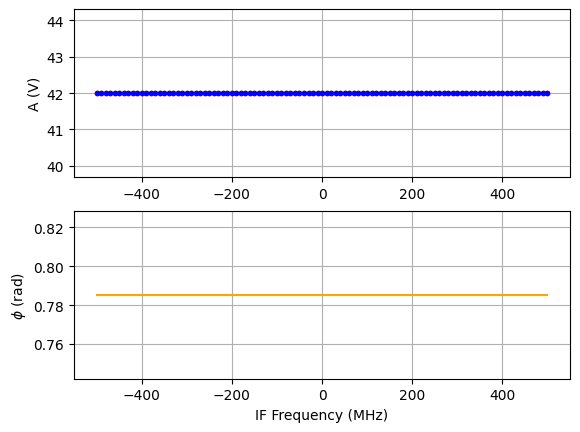

In [17]:
data_test = run_simple_test.get_data("ac_0")
freq_test = run_simple_test.get_axis("ac_0")[0]
# print(data_test)
# print(freq_test)

# plot the measurement data
fig, [ax1, ax2] = plt.subplots(2, 1)
ax1.plot(freq_test / 1e6, np.real(data_test), ".-r")
ax1.plot(freq_test / 1e6, np.imag(data_test), ".-b")
ax2.plot(freq_test / 1e6, np.unwrap(np.angle(data_test)), "orange")
ax1.set_ylabel("A (V)")
ax2.set_ylabel("$\\phi$ (rad)")
ax2.set_xlabel("IF Frequency (MHz)")
# ax1.set_yscale('log')
ax1.grid()
ax2.grid()
plt.show()